In [1]:
# Installation and set up
!pip install kagglehub[pandas-datasets]


In [2]:
# Imports
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
# Set the path to the file you'd like to load
file_path = "cleaned_canada.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yuliiabulana/canada-housing",
  file_path,
)

df.head()

/tmp/ipykernel_46506/108312568.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 5.41M/5.41M [00:00<00:00, 46.5MB/s]


,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,...,Exterior,Fireplace,Heating,Flooring,Roof,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,...,NaN,No,heat pump,carpet,NaN,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,...,NaN,No,heat pump,NaN,NaN,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,...,Metal,No,NaN,laminate,tar,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,...,NaN,Yes,forced air,NaN,NaN,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,...,NaN,No,radiant,NaN,NaN,No,none,No,No,No


In [ ]:
df.describe()

,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Square Footage
count,44896.000000,44896.000000,4.489600e+04,44896.000000,44896.000000,44896.000000,44896.000000
mean,49.010267,-106.632760,1.070457e+06,3.214919,2.522652,2.485950,1787.726323
std,2.659066,22.270395,1.442961e+06,1.636517,1.423765,86.626599,1988.320406
min,42.045940,-135.856018,5.000000e+04,0.000000,0.000000,0.000000,140.000000
25%,48.477511,-122.887882,3.999900e+05,2.000000,2.000000,0.000000,975.000000
50%,49.217891,-119.395219,6.880000e+05,3.000000,2.000000,0.060000,1417.000000
75%,49.927914,-102.485638,1.200000e+06,4.000000,3.000000,0.180000,2198.000000
max,65.281488,-52.668600,5.880000e+07,37.000000,26.000000,8600.000000,290034.000000


# 1. Data Preparation

## 1.1. Determining the best model to use for classification

In [4]:
# Drop rows with missing basement values to prepare training data
train_df = df.dropna(subset=['Basement'])

# Convert categorical values to valid data types (one-hot encoding)
train_df = pd.get_dummies(train_df, columns=['Garden', 'Property Type'], drop_first=True)

# Split data
midpoint = train_df.index.size // 2
train_data = train_df.iloc[:midpoint]
test_data = train_df.iloc[midpoint:]

# Get generated dummy column names for City and Property Type
garden_cols = [col for col in train_df.columns if col.startswith('Garden_')]
proptype_cols = [col for col in train_df.columns if col.startswith('Property Type_')]
feature_cols = ['Square Footage'] + garden_cols + proptype_cols

X_train = train_data[feature_cols]
X_test = test_data[feature_cols]
y_train = train_data['Basement']
y_test = test_data['Basement']

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
lda_preds = lda.predict(X_test)

conf = confusion_matrix(y_test, lda_preds, labels=lda.classes_)
print('Confusion matrix:\n')
print(lda.classes_)
print(conf)
acc = accuracy_score(y_test, lda_preds)
print('\nAccuracy: ', acc)

Confusion matrix:

['Finished' 'No basement' 'Partial']
[[5665    0    0]
 [1412    0    0]
 [ 404    0    0]]

Accuracy:  0.7572517043176046


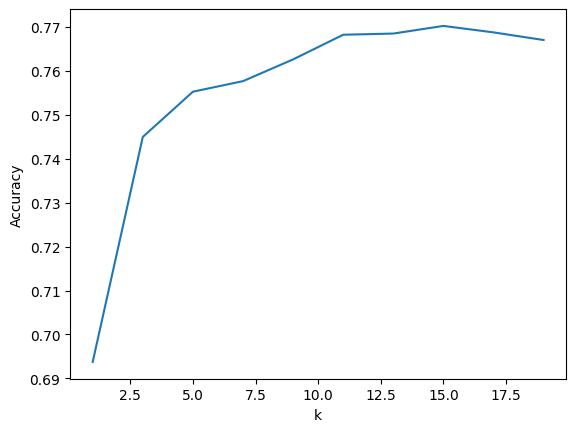


Best k value: 15


In [9]:
# Find the best k value
k_values = range(1, 20, 2)
accs = []

for k in k_values:
  knn = KNeighborsClassifier(k)
  knn.fit(X_train, y_train)
  accs.append(accuracy_score(y_test, knn.predict(X_test)))

plt.plot(k_values, accs)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

print('\nBest k value:', k_values[accs.index(max(accs))])

In [10]:
# KNN with k = 15
knn = KNeighborsClassifier(15)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

conf = confusion_matrix(y_test, knn_preds, labels=knn.classes_)
print('Confusion matrix:\n')
print(knn.classes_)
print(conf)
acc = accuracy_score(y_test, knn_preds)
print('\nAccuracy: ', acc)

Confusion matrix:

['Finished' 'No basement' 'Partial']
[[5623   41    1]
 [1271  138    3]
 [ 387   16    1]]

Accuracy:  0.7702178853094506


In [11]:
# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

conf = confusion_matrix(y_test, logreg_preds, labels=logreg.classes_)
print('Confusion matrix:\n')
print(logreg.classes_)
print(conf)
acc = accuracy_score(y_test, logreg_preds)
print('\nAccuracy: ', acc)

Confusion matrix:

['Finished' 'No basement' 'Partial']
[[5665    0    0]
 [1412    0    0]
 [ 404    0    0]]

Accuracy:  0.7572517043176046


## 1.2 Using KNN classification to predict and fill missing data points

In [13]:
# Get all rows with missing basement values
missing_data = df[df['Basement'].isna()]
missing_data = pd.get_dummies(missing_data, columns=['Garden', 'Property Type'], drop_first=True)

# Predict missing data
X_missing = scaler.transform(missing_data[feature_cols])
preds = knn.predict(X_missing)

# Merge with original dataframe
filled_df = df.copy()
filled_df.loc[missing_data.index, 'Basement'] = preds

# Testing
print(filled_df['Basement'].isna().sum())  # All missing basement values filled
print (df.index.size == filled_df.index.size)  # No rows dropped

0
True


# 2. Pre-training

## 2.1. Using Clustering to divide data into related clusters

# 3. Training

## 3.1 Regression on Clusters to build Price Predictor

# 4. Calculate Readl Estate Deals

## 4.1 Finding the top 5 deals in each cluster